In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import transforms
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [ ]:
path = kagglehub.dataset_download("helofalak/fashion-minset-test")
print("path:", path)

Using Colab cache for faster access to the 'fashion-minset-test' dataset.
path: /kaggle/input/fashion-minset-test


In [ ]:
df = pd.read_csv("/kaggle/input/fashion-minset-test/fashion-mnist_test.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.shape

(10000, 785)

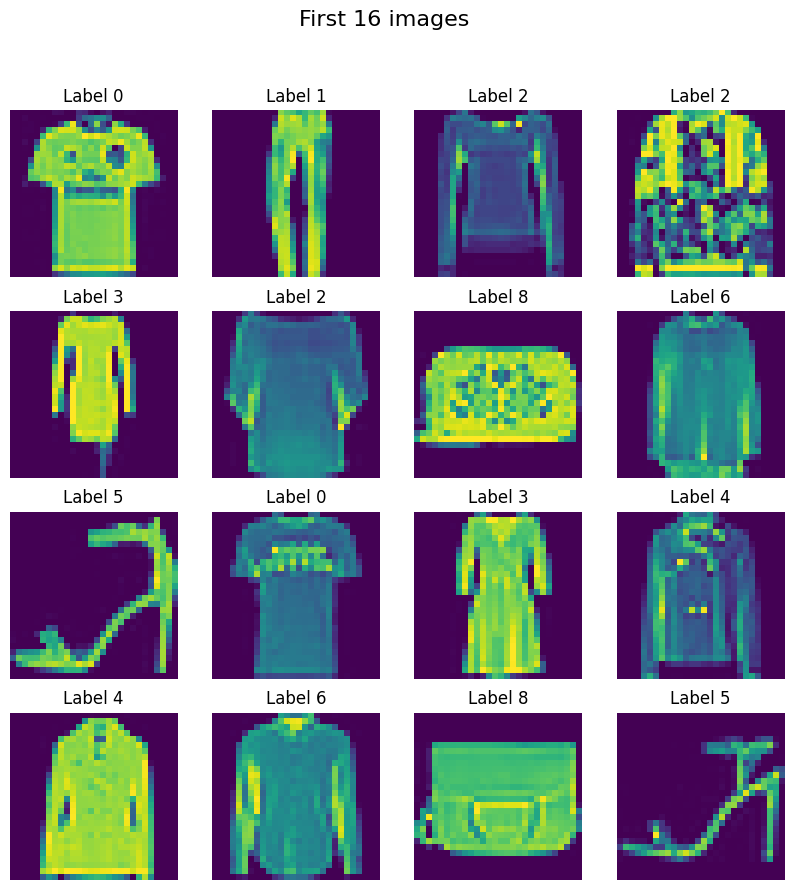

In [ ]:
fig, axes = plt.subplots(4,4, figsize=(10,10))
fig.suptitle("First 16 images", fontsize=16)

for i, ax in enumerate(axes.flat):
  img = df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')

  ax.set_title(f"Label {df.iloc[i,0]}")

In [ ]:
len(df.iloc[:,1:])

10000

In [ ]:
df['label'].unique()

array([0, 1, 2, 3, 8, 6, 5, 4, 7, 9])

In [ ]:
# train test split
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

## Custom Dataset

In [ ]:
class MultiClassClassfication(Dataset):
  def __init__(self, df):
    self.labels = y
    self.images = X

  def __len__(self):
    return len(self.labels)

  def __getitem__(self, idx):
    image = torch.tensor(self.images[idx], dtype=torch.float32)
    image = image.view(1, 28, 28)

    label = torch.tensor(self.labels[idx], dtype=torch.long)

    return image, label


## Load Data

In [ ]:
dataset = MultiClassClassfication(df)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

''' can also done for the csv dataset
# Split DataFrame
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Create datasets
train_dataset = FashionMNISTDataset(train_df)
test_dataset = FashionMNISTDataset(test_df)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
'''

' can also done for the csv dataset\n# Split DataFrame\ntrain_df, test_df = train_test_split(df, test_size=0.2, random_state=42)\n\n# Create datasets\ntrain_dataset = FashionMNISTDataset(train_df)\ntest_dataset = FashionMNISTDataset(test_df)\n\n# DataLoaders\ntrain_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)\ntest_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)\n'

## CNN Model

In [ ]:
class MyCNN(nn.Module):
  def __init__(self, num_classes=10):
    super().__init__()

    self.features = nn.Sequential(
        #block 1
        nn.Conv2d(1 ,32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.BatchNorm2d(32),
        nn.Conv2d(32, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.BatchNorm2d(32),
        nn.MaxPool2d(2),

        #block 2
        nn.Conv2d(32 , 64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.BatchNorm2d(64),
        nn.Conv2d(64, 64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(2),

        #block 3
        nn.Conv2d(64 ,128 , kernel_size=3, padding=1),
        nn.ReLU(),
        nn.BatchNorm2d(128),
        nn.Conv2d(128, 128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.BatchNorm2d(128),
        nn.MaxPool2d(2),

        #block 4
        nn.Conv2d(128 ,256 , kernel_size=3, padding=1),
        nn.ReLU(),
        nn.BatchNorm2d(256),
        nn.Conv2d(256, 256, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.BatchNorm2d(256),
        nn.MaxPool2d(2),
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(256 * 1 * 1, 128),
        nn.ReLU(),
        nn.Dropout(0.1),

        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(0.2),

        nn.Linear(64, num_classes)
    )


  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)
    return x


In [ ]:
model = MyCNN(num_classes=10)

In [ ]:
criterion = nn.CrossEntropyLoss()  # Loss function
optimizer = optim.Adam(model.parameters(), lr= 0.001)  # Optimizer

# Training

In [ ]:
epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")


Epoch 1/10, Loss: 0.7105
Epoch 2/10, Loss: 0.4078
Epoch 3/10, Loss: 0.3451
Epoch 4/10, Loss: 0.2725
Epoch 5/10, Loss: 0.2476
Epoch 6/10, Loss: 0.2110
Epoch 7/10, Loss: 0.1873
Epoch 8/10, Loss: 0.1591
Epoch 9/10, Loss: 0.1549
Epoch 10/10, Loss: 0.1424


## Evaluation Function

In [ ]:
def evaluate(loader):
  model.eval()
  correct = 0
  total = 0

  with torch.no_grad():
      for images, labels in loader:
          outputs = model(images)
          _, predicted = torch.max(outputs, 1)

          total += labels.size(0)
          correct += (predicted == labels).sum().item()

  return correct / total

In [ ]:
test_acc = evaluate(test_loader)
print("Test Accuracy:", test_acc)

Test Accuracy: 0.9065
